Regiones y fronteras

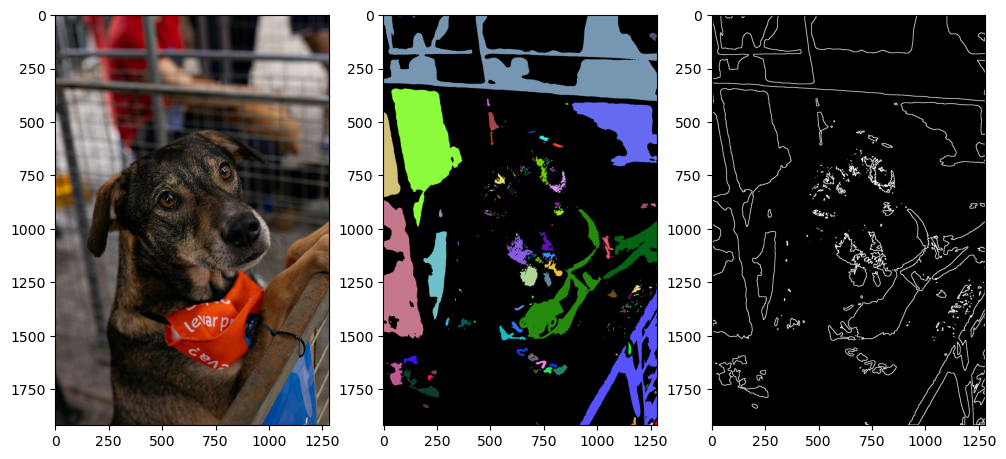

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('perro.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# combinamos tecnicas para preparas la imagen
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#encontramos las regiones
num_l, label = cv2.connectedComponents(binary)
#identificamos por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
color[0] = [0, 0, 0]
colorear = color[label]

#encontrar fronteras
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(132)
plt.imshow(colorear)
plt.subplot(133)
plt.imshow(contornos_fin, cmap='gray')
plt.show()

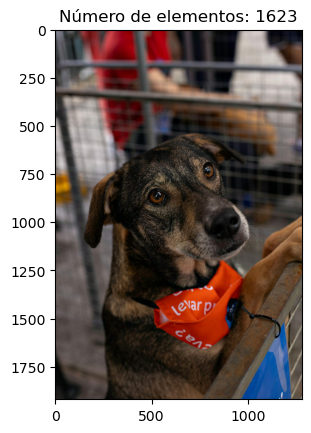

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    e_img = measure.label(binary, connectivity=2) # 2=conectividad es 4 1 = con 
    num_obj = np.max(e_img)
    return num_obj
imagen = cv2.imread('perro.jpg')
conteo = contar_elementos(imagen)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f'Número de elementos: {conteo}')
plt.show()


--- ELEMENTOS POR COLOR (Regiones) ---
Región 1 (Color RGB [236 251  78]): 217318 píxeles
Región 2 (Color RGB [ 50 175 221]): 599 píxeles
Región 3 (Color RGB [ 40  38 182]): 213 píxeles
Región 4 (Color RGB [190 126 226]): 875 píxeles
Región 5 (Color RGB [240 152 167]): 104881 píxeles
Región 6 (Color RGB [156  18  27]): 291 píxeles
Región 7 (Color RGB [158  67  63]): 320 píxeles
Región 8 (Color RGB [ 79 143  17]): 62233 píxeles
Región 9 (Color RGB [144  53 236]): 100 píxeles
Región 10 (Color RGB [ 99 116 202]): 20308 píxeles
Región 11 (Color RGB [247 170 116]): 2359 píxeles
Región 12 (Color RGB [216  81  69]): 27 píxeles
Región 13 (Color RGB [  5 177  61]): 48 píxeles
Región 14 (Color RGB [171 145  20]): 242 píxeles
Región 15 (Color RGB [ 21 199 113]): 495 píxeles
Región 16 (Color RGB [196 115 219]): 12 píxeles
Región 17 (Color RGB [173 226 177]): 637 píxeles
Región 18 (Color RGB [120  91  89]): 27 píxeles
Región 19 (Color RGB [205 150 223]): 519 píxeles
Región 20 (Color RGB [133  35 16

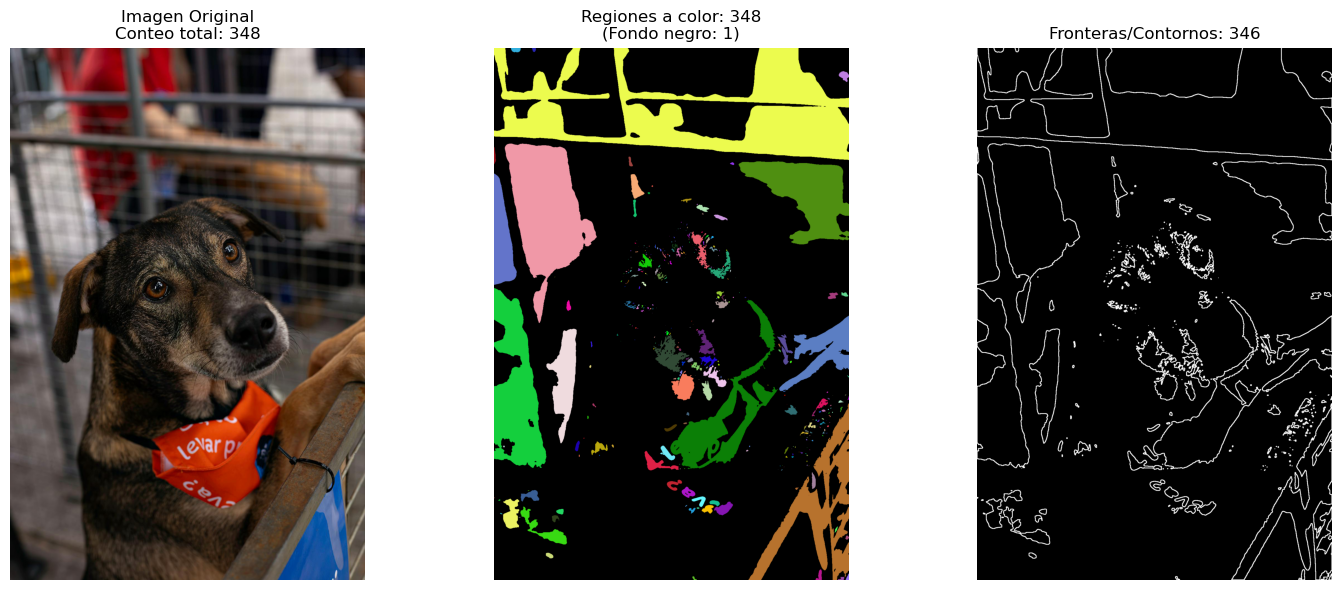

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('perro.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# REGIONES: Usamos WithStats para obtener el tamaño (píxeles) de cada región
num_l, label, stats, centroids = cv2.connectedComponentsWithStats(binary)
num_elementos = num_l - 1

color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
color[0] = [0, 0, 0]
colorear = color[label]

print("--- ELEMENTOS POR COLOR (Regiones) ---")
for i in range(1, num_l):
    area_pixeles = stats[i, cv2.CC_STAT_AREA]
    print(f"Región {i} (Color RGB {color[i]}): {area_pixeles} píxeles")


contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
num_fronteras = len(contornos)
contornos_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

print("\n--- ELEMENTOS POR FRONTERA (Contornos) ---")
for i, contorno in enumerate(contornos):
    puntos_frontera = len(contorno)
    print(f"Frontera {i+1}: {puntos_frontera} puntos de contorno")

# Visualizamos
plt.figure(figsize=(15, 6))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Imagen Original\nConteo total: {num_elementos}')
plt.axis('off')

plt.subplot(132)
plt.imshow(colorear)
plt.title(f'Regiones a color: {num_elementos}\n(Fondo negro: 1)')
plt.axis('off')

plt.subplot(133)
plt.imshow(contornos_fin, cmap='gray')
plt.title(f'Fronteras/Contornos: {num_fronteras}')
plt.axis('off')

plt.tight_layout()
plt.show()